In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)

import sys
sys.path.append("/ihome/ylee/yiz133/Code/Data processing/functions")
import importlib
import mdata_utils
import TCR_embedings

2025-11-30 18:46:27.419940: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-30 18:46:27.420317: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-30 18:46:27.485593: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-30 18:46:30.565508: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA

In [3]:
importlib.reload(TCR_embedings)

<module 'TCR_embedings' from '/ihome/ylee/yiz133/Code/Data processing/functions/TCR_embedings.py'>

In [4]:
%cd "/ix1/ylee/Yifan_Zhang/Code_data/external"

/ix1/ylee/Yifan_Zhang/Code_data/external


In [63]:
filename = "EAE_HV_then_merged"
mdata_ori = mu.read(filename + ".h5mu")

In [64]:
mdata = mdata_ori.copy()
mdata

MuData object with n_obs × n_vars = 125524 × 3001
  obs:	'GSE', 'GSM', 'VDJ_1_cdr3_aa', 'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_cdr3_aa', 'VJ_1_j_call', 'VJ_1_v_call', 'cell_type', 'cloned', 'condition', 'sample_id', 'set', 'state'
  2 modalities
    airr:	125524 x 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonal_expansion', 'sample', 'tissue', 'condition'
      obsm:	'airr', 'chain_indices'
    gex:	125524 x 3001
      obs:	'sample_id', 'date', 'tissue', 'sample', 'mouse_BC', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'CD4score', 'CD8score', 'Tregscore', 'Th17score', 'cell_type', 'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore', 'state', 'TCR_clonotype_frequency', 'condition', 'batch', 'leiden', 'GSE'
      var:	'gene_ids', 'feature_types', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'GSE_colors', 'X_umap_harmony', 'cell_type_colors', 'leiden', 'neighbors', 'neighbors_harmony', 'pca', 'state_colors', 'tissue_colors', 'umap'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_harmony'
      varm:	'PCs'
      obsp:	'connectivities', 'distances', 'neighbors_harmony_connectivities', 'neighbors_harmony_distances'

In [65]:
mdata['airr'].obs['GSE'] = mdata.obs['GSE']
mdata['airr'].obs['GSE'].value_counts()

GSE
LEE          43558
GSE182747    37164
GSE188320    22346
GSE293883    11097
GSE156718    10848
GSE178085      511
Name: count, dtype: int64

# Settings

In [66]:
# mdata_sets = {'all': mdata,
#             'cloned': mdata_cloned,
#             'one_in_each_clone': mdata_cloned_oneCell}
# mdata_sub = mdata_sets['cloned']

### Sets to use
subset_by_GSE = False
if subset_by_GSE == True:
    target_set = ['GSE188320', 'GSE178085']
    mdata = mdata[mdata.obs['GSE'].isin(target_set)]
    
    # redo harmony in the subset
    import scanpy.external as sce
    sc.pp.pca(mdata["gex"], n_comps=50)
    sc.pp.neighbors(mdata["gex"], n_neighbors = 50)
    sc.tl.umap(mdata["gex"], min_dist=0.5, spread=1.0)
    sce.pp.harmony_integrate(mdata["gex"], key=["GSE", 'sample_id'],  basis='X_pca',
                          theta = 3, lamb = 1,  sigma=0.1, nclust = 50, tau=1)


### If test group is isolated
if_test_isolated = True
if if_test_isolated == True:
    test_ids = ['GSE293883']
else:
    train_frac = 0.7
    
### If use x_umap of X_umap_harmony
Batch_corrected = True

mdata    

MuData object with n_obs × n_vars = 125524 × 3001
  obs:	'GSE', 'GSM', 'VDJ_1_cdr3_aa', 'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_cdr3_aa', 'VJ_1_j_call', 'VJ_1_v_call', 'cell_type', 'cloned', 'condition', 'sample_id', 'set', 'state'
  2 modalities
    airr:	125524 x 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonal_expansion', 'sample', 'tissue', 'condition', 'GSE'
      obsm:	'airr', 'chain_indices'
    gex:	125524 x 3001
      obs:	'sample_id', 'date', 'tissue', 'sample', 'mouse_BC', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'CD4score', 'CD8score', 'Tregscore', 'Th17score', 'cell_type', 'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore', 'state', 'TCR_clonotype_frequency', 'condition', 'batch', 'leiden', 'GSE'
      var:	'gene_ids', 'feature_types', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'GSE_colors', 'X_umap_harmony', 'cell_type_colors', 'leiden', 'neighbors', 'neighbors_harmony', 'pca', 'state_colors', 'tissue_colors', 'umap'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_harmony'
      varm:	'PCs'
      obsp:	'connectivities', 'distances', 'neighbors_harmony_connectivities', 'neighbors_harmony_distances'

# data pre-vision

In [67]:
mdata['gex'].obs['tissue'].isna().sum()

np.int64(6774)

In [68]:
# mdata['gex'].obs['Tissue_group'] = mdata['gex'].obs['tissue'].apply(lambda x: x if (x == 'CNS' or x =='Spleen') else 'else')

mdata['gex'].obs['Tissue_group'] = mdata['gex'].obs['tissue'].apply(lambda x: x if (x == 'CNS') else 'non-CNS')
mdata['gex'].obs['Tissue_group'].value_counts()

Tissue_group
non-CNS    69141
CNS        49609
Name: count, dtype: int64

In [69]:
mdata['gex'].obs['Tissue_group'].isna().sum()

np.int64(6774)

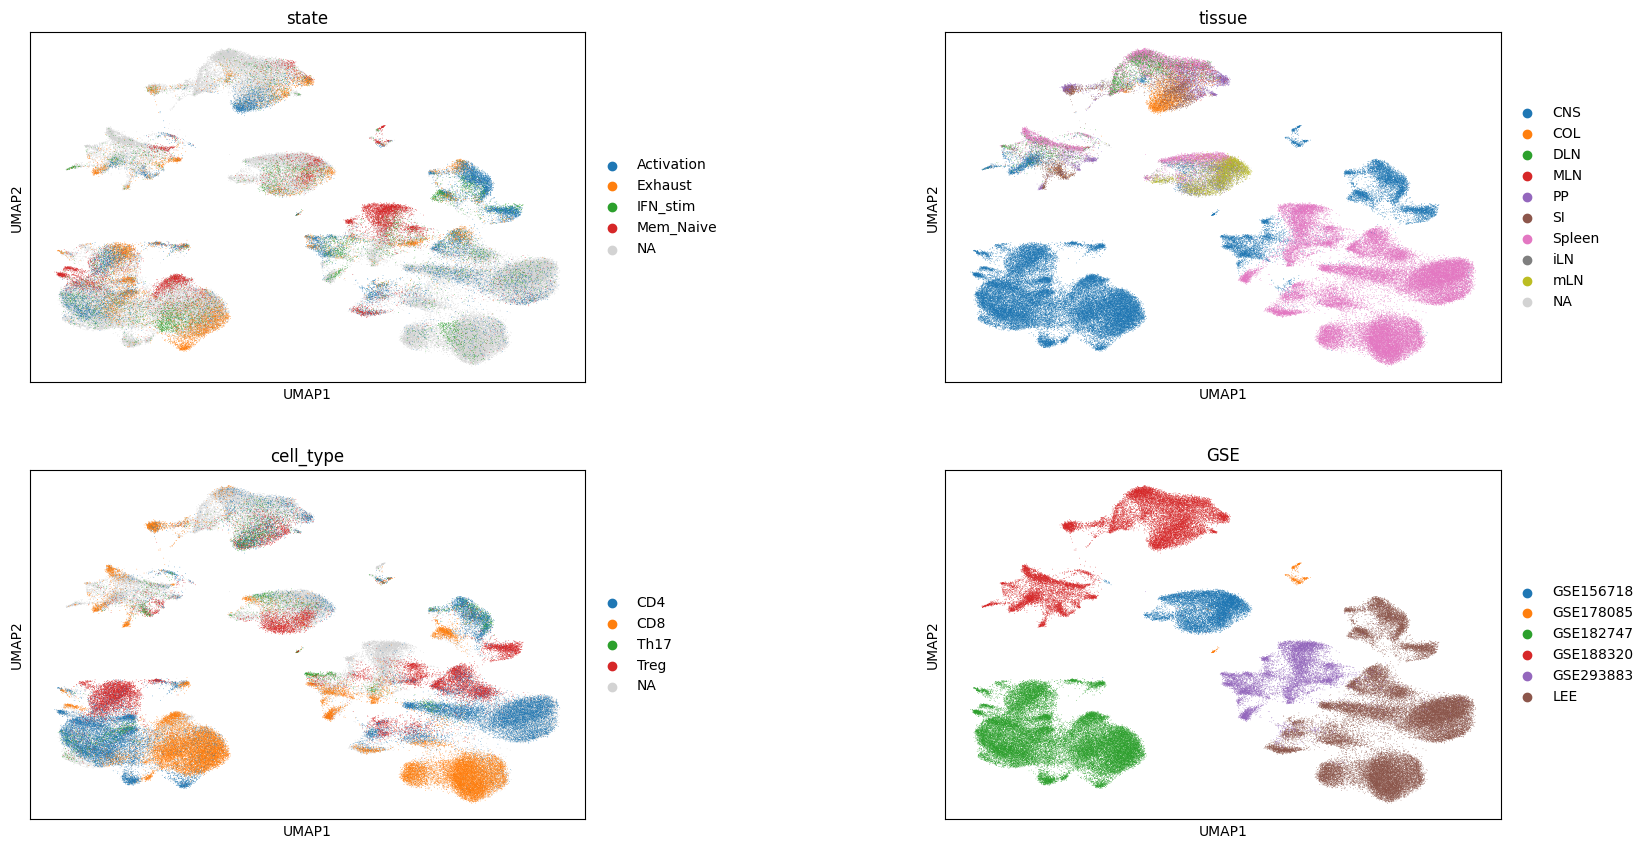

In [70]:
sc.pl.umap(mdata["gex"], color=['state', 'tissue', 'cell_type', 'GSE'], ncols=2, wspace=0.5)

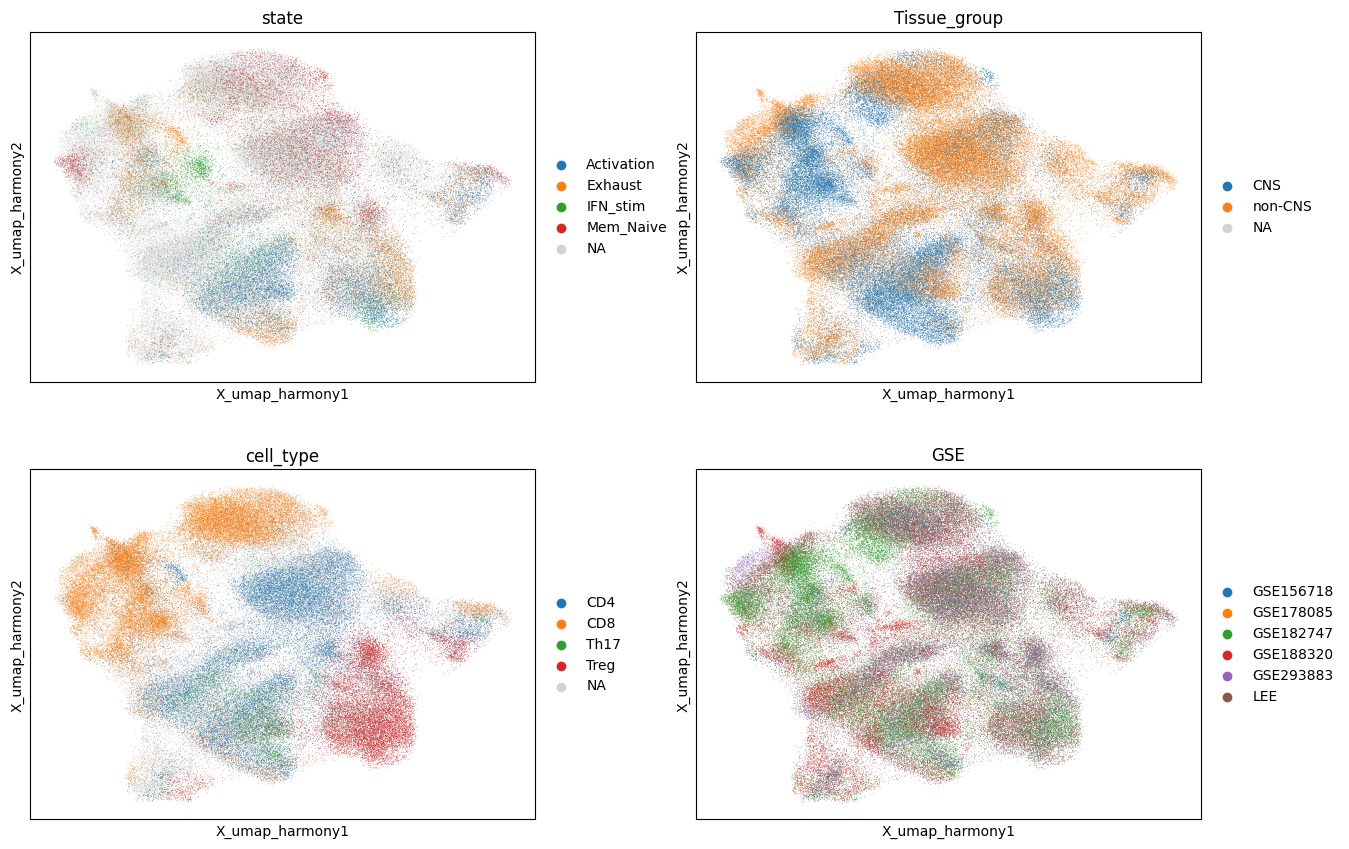

In [71]:
gene_PCA = 'X_pca_harmony' if Batch_corrected else 'X_pca'
gene_Umap = 'X_umap_harmony' if Batch_corrected else 'X_umap'
neighbors_key = 'neighbors_harmony' if Batch_corrected else 'neighbors'

sc.pl.embedding(mdata["gex"], basis = gene_Umap, neighbors_key = neighbors_key, 
                color=['state', 'Tissue_group', 'cell_type', 'GSE'], ncols=2, wspace=0.2)

# Subsets

#### Cell type subset

In [72]:
# print(mdata.obs['condition'].value_counts())
# print(mdata.obs['cell_type'].value_counts())
# print(mdata['gex'].obs['tissue'].value_counts())

In [73]:
# mdata = mdata[mdata.obs['condition'].isin(['EAE'])]
# mdata = mdata[~mdata.obs['cell_type'].isin(['CD8'])]

# Suppose mdata['gex'].obs has columns 'state' and 'cell_type'
# cols = ['state', 'cell_type']
# mask = mdata['gex'].obs[cols].notna().all(axis=1)
# mdata = mdata[mask].copy()

In [74]:
mdata

MuData object with n_obs × n_vars = 125524 × 3001
  obs:	'GSE', 'GSM', 'VDJ_1_cdr3_aa', 'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_cdr3_aa', 'VJ_1_j_call', 'VJ_1_v_call', 'cell_type', 'cloned', 'condition', 'sample_id', 'set', 'state'
  2 modalities
    airr:	125524 x 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonal_expansion', 'sample', 'tissue', 'condition', 'GSE'
      obsm:	'airr', 'chain_indices'
    gex:	125524 x 3001
      obs:	'sample_id', 'date', 'tissue', 'sample', 'mouse_BC', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'CD4score', 'CD8score', 'Tregscore', 'Th17score', 'cell_type', 'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore', 'state', 'TCR_clonotype_frequency', 'condition', 'batch', 'leiden', 'GSE', 'Tissue_group'
      var:	'gene_ids', 'feature_types', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'GSE_colors', 'X_umap_harmony', 'cell_type_colors', 'leiden', 'neighbors', 'neighbors_harmony', 'pca', 'state_colors', 'tissue_colors', 'umap', 'Tissue_group_colors'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_harmony'
      varm:	'PCs'
      obsp:	'connectivities', 'distances', 'neighbors_harmony_connectivities', 'neighbors_harmony_distances'

#### only cloned TCRs

In [75]:
min_clone = 1
cloned_mask = mdata['airr'].obs['clone_id_size'].fillna(0).astype('int') > min_clone
mdata_cloned = mdata[cloned_mask].copy()
mdata_single = mdata[~cloned_mask].copy()
mdata_cloned['airr'].obs['GSE'].value_counts()

GSE
GSE182747    26215
GSE188320    15885
LEE           6310
GSE156718     3182
GSE293883     2483
GSE178085      511
Name: count, dtype: int64

#### select only one cell from each clonotype

In [76]:
# Randomly keep one cell per clone_id within each GSE subset
airr = mdata_cloned['airr']
# airr = mdata['airr']
print(f"Original number of cells: {airr.n_obs}")

# Store indices to keep
oneCell_per_clone_indices = []

# Group by GSE
for gse in airr.obs['GSE'].unique():
    # Get cells for this GSE
    gse_mask = airr.obs['GSE'] == gse
    gse_obs = airr.obs[gse_mask]
    
    print(f"\nGSE: {gse} - Original cells: {len(gse_obs)}")
    
    # For each clone_id in this GSE, randomly select one cell
    for clone_id in gse_obs['clone_id'].dropna().unique():
        clone_cells = gse_obs[gse_obs['clone_id'] == clone_id]
        if len(clone_cells) > 1:
        # Randomly sample one cell from this clone
            selected_idx = clone_cells.sample(n=1, random_state=42).index[0]
            oneCell_per_clone_indices.append(selected_idx)
        else:
            oneCell_per_clone_indices.append(clone_cells.index[0])
    
    print(f"GSE: {gse} - After sampling: {len(gse_obs['clone_id'].unique())} cells (one per clone)")

# Create subset with selected cells
mdata_cloned_oneCell = mdata[oneCell_per_clone_indices].copy()


Original number of cells: 54586

GSE: LEE - Original cells: 6310
GSE: LEE - After sampling: 1689 cells (one per clone)

GSE: GSE156718 - Original cells: 3182
GSE: GSE156718 - After sampling: 1111 cells (one per clone)

GSE: GSE182747 - Original cells: 26215
GSE: GSE182747 - After sampling: 3542 cells (one per clone)

GSE: GSE178085 - Original cells: 511
GSE: GSE178085 - After sampling: 2 cells (one per clone)

GSE: GSE188320 - Original cells: 15885
GSE: GSE188320 - After sampling: 2597 cells (one per clone)

GSE: GSE293883 - Original cells: 2483
GSE: GSE293883 - After sampling: 652 cells (one per clone)


## select subset

In [77]:
single_per_clone = list(mdata_single.obs['GSE'].index) + oneCell_per_clone_indices
mdata_all_singe = mdata[single_per_clone].copy()

mdata = mdata_single
mdata

MuData object with n_obs × n_vars = 70938 × 3001
  obs:	'GSE', 'GSM', 'VDJ_1_cdr3_aa', 'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_cdr3_aa', 'VJ_1_j_call', 'VJ_1_v_call', 'cell_type', 'cloned', 'condition', 'sample_id', 'set', 'state'
  2 modalities
    airr:	70938 x 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonal_expansion', 'sample', 'tissue', 'condition', 'GSE'
      obsm:	'airr', 'chain_indices'
    gex:	70938 x 3001
      obs:	'sample_id', 'date', 'tissue', 'sample', 'mouse_BC', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'CD4score', 'CD8score', 'Tregscore', 'Th17score', 'cell_type', 'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore', 'state', 'TCR_clonotype_frequency', 'condition', 'batch', 'leiden', 'GSE', 'Tissue_group'
      var:	'gene_ids', 'feature_types', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'GSE_colors', 'X_umap_harmony', 'cell_type_colors', 'leiden', 'neighbors', 'neighbors_harmony', 'pca', 'state_colors', 'tissue_colors', 'umap', 'Tissue_group_colors'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_harmony'
      varm:	'PCs'
      obsp:	'connectivities', 'distances', 'neighbors_harmony_connectivities', 'neighbors_harmony_distances'

# embed TCR AA into vector

In [78]:
# beta chain only
# tcr_aa_obs = ['VDJ_1_cdr3_aa',]
# tcr_cat_features = ['VDJ_1_j_call', 'VDJ_1_v_call']

# both chains
tcr_aa_obs = ['VDJ_1_cdr3_aa', 'VJ_1_cdr3_aa']
tcr_cat_features = ['VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call']

tcr_num_features = []

In [79]:
# Atchley factors for the 20 amino acids
atchley_factors = {
    'A': [ 0.591, -1.302, -0.733,  1.570, -0.146],  # Alanine
    'R': [ 1.538,  0.055,  1.502,  0.440,  2.897],  # Arginine
    'N': [ 0.945,  0.828,  1.299, -0.169,  0.933],  # Asparagine
    'D': [ 1.050,  0.302, -3.656, -0.259, -3.242],  # Aspartic acid
    'C': [-1.343,  0.465, -0.862, -1.020, -0.255],  # Cysteine
    'Q': [ 0.931,  0.179, -3.005, -0.503, -1.853],  # Glutamine
    'E': [ 1.357,  0.113, -3.242, -0.339, -2.192],  # Glutamic acid
    'G': [ 0.384,  1.652,  1.330,  1.045,  2.064],  # Glycine
    'H': [ 0.336, -0.417, -1.673, -1.474, -0.078],  # Histidine
    'I': [-1.239, -0.547,  2.131,  0.393,  0.816],  # Isoleucine
    'L': [-1.019, -0.987, -1.505,  1.266, -0.912],  # Leucine
    'K': [ 1.831, -0.561,  0.533, -0.277,  1.648],  # Lysine
    'M': [-0.663, -1.524,  2.219, -1.005,  1.212],  # Methionine
    'F': [-1.006, -0.590,  1.891, -0.397,  0.412],  # Phenylalanine
    'P': [ 0.189,  2.081, -1.628,  0.421, -1.392],  # Proline
    'S': [ 0.228,  1.399, -4.760,  0.670, -2.647],  # Serine
    'T': [ 0.032,  2.213, -1.455,  0.311, -0.259],  # Threonine
    'W': [-0.595,  0.009,  0.672, -2.128, -0.184],  # Tryptophan
    'Y': [ 0.260,  0.830,  3.097, -0.838,  1.512],  # Tyrosine
    'V': [-1.337, -0.279, -0.544,  1.242, -1.262],  # Valine
}


In [80]:
# Vectorize each TCR amino acid column and compute composition & length
for aa_col in tcr_aa_obs:
    # 1. Sequence length
    # Only keep cells with both alpha and beta chains
    lengths = TCR_embedings.compute_sequence_lengths(mdata, aa_col)
    lengths_mask = (lengths> 10) & (lengths< 20)
    len_key = f'{aa_col}_length'
    mdata = mdata[lengths_mask]
    mdata.obs[len_key] = lengths[lengths_mask]
    print(f"Stored {aa_col} lengths in mdata.obs['{len_key}']")
    
    # 2. Atchley factor encoding
    encoded = TCR_embedings.vectorize_tcr_column(mdata, aa_col, atchley_factors)
    key_name = f'X_{aa_col}_atchley'
    mdata.obsm[key_name] = encoded
    print(f"Stored {aa_col} Atchley vectors in mdata.obsm['{key_name}'] with shape {encoded.shape}")
    
    # 2b. Adjacent Atchley factor interactions
    atchley_positions = encoded.shape[1] // 5
    pairwise_key = f'X_{aa_col}_atchley_pairwise'
    if atchley_positions > 1:
        encoded_reshaped = encoded.reshape(encoded.shape[0], atchley_positions, 5)
        pairwise_features = []
        for pos in range(atchley_positions - 1):
            current = encoded_reshaped[:, pos, :]
            nxt = encoded_reshaped[:, pos + 1, :]
            outer = (current[:, :, None] * nxt[:, None, :]).reshape(encoded.shape[0], -1)
            pairwise_features.append(outer)
        pairwise_matrix = np.concatenate(pairwise_features, axis=1)
    else:
        pairwise_matrix = np.zeros((encoded.shape[0], 0))
    mdata.obsm[pairwise_key] = pairwise_matrix
    print(f"Stored {aa_col} adjacent Atchley interactions in mdata.obsm['{pairwise_key}'] with shape {pairwise_matrix.shape}")    
    
    # 3. AA composition (percentage of each of 20 AAs)
    aa_comp = TCR_embedings.compute_aa_composition_matrix(mdata, aa_col)
    comp_key = f'X_{aa_col}_composition'
    mdata.obsm[comp_key] = aa_comp
    print(f"Stored {aa_col} AA composition in mdata.obsm['{comp_key}'] with shape {aa_comp.shape}\n")
    

Stored VDJ_1_cdr3_aa lengths in mdata.obs['VDJ_1_cdr3_aa_length']
Stored VDJ_1_cdr3_aa Atchley vectors in mdata.obsm['X_VDJ_1_cdr3_aa_atchley'] with shape (56699, 100)
Stored VDJ_1_cdr3_aa adjacent Atchley interactions in mdata.obsm['X_VDJ_1_cdr3_aa_atchley_pairwise'] with shape (56699, 475)
Stored VDJ_1_cdr3_aa AA composition in mdata.obsm['X_VDJ_1_cdr3_aa_composition'] with shape (56699, 20)

Stored VJ_1_cdr3_aa lengths in mdata.obs['VJ_1_cdr3_aa_length']
Stored VJ_1_cdr3_aa Atchley vectors in mdata.obsm['X_VJ_1_cdr3_aa_atchley'] with shape (40484, 100)
Stored VJ_1_cdr3_aa adjacent Atchley interactions in mdata.obsm['X_VJ_1_cdr3_aa_atchley_pairwise'] with shape (40484, 475)
Stored VJ_1_cdr3_aa AA composition in mdata.obsm['X_VJ_1_cdr3_aa_composition'] with shape (40484, 20)



In [81]:
mdata

MuData object with n_obs × n_vars = 40484 × 3001
  obs:	'GSE', 'GSM', 'VDJ_1_cdr3_aa', 'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_cdr3_aa', 'VJ_1_j_call', 'VJ_1_v_call', 'cell_type', 'cloned', 'condition', 'sample_id', 'set', 'state', 'VDJ_1_cdr3_aa_length', 'VJ_1_cdr3_aa_length'
  obsm:	'X_VDJ_1_cdr3_aa_atchley', 'X_VDJ_1_cdr3_aa_atchley_pairwise', 'X_VDJ_1_cdr3_aa_composition', 'X_VJ_1_cdr3_aa_atchley', 'X_VJ_1_cdr3_aa_atchley_pairwise', 'X_VJ_1_cdr3_aa_composition'
  2 modalities
    airr:	40484 x 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonal_expansion', 'sample', 'tissue', 'condition', 'GSE'
      obsm:	'airr', 'chain_indices'
    gex:	40484 x 3001
      obs:	'sample_id', 'date', 'tissue', 'sample', 'mouse_BC', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'CD4score', 'CD8score', 'Tregscore', 'Th17score', 'cell_type', 'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore', 'state', 'TCR_clonotype_frequency', 'condition', 'batch', 'leiden', 'GSE', 'Tissue_group'
      var:	'gene_ids', 'feature_types', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'GSE_colors', 'X_umap_harmony', 'cell_type_colors', 'leiden', 'neighbors', 'neighbors_harmony', 'pca', 'state_colors', 'tissue_colors', 'umap', 'Tissue_group_colors'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_harmony'
      varm:	'PCs'
      obsp:	'connectivities', 'distances', 'neighbors_harmony_connectivities', 'neighbors_harmony_distances'

In [82]:
# One-hot encode all categorical TCR features and concatenate
cat_encoded_list = []
for cat_col in tcr_cat_features:
    encoded = TCR_embedings.onehot_encode_categorical(mdata, cat_col)
    # cat_encoded_list.append(encoded)
    mdata.obsm[cat_col] = encoded

# Concatenate all one-hot encoded vectors
# tcr_cat_onehot = np.concatenate(cat_encoded_list, axis=1)


VDJ_1_j_call: 12 unique categories + 1 unknown = 13 dimensions
VDJ_1_v_call: 23 unique categories + 1 unknown = 24 dimensions
VJ_1_j_call: 42 unique categories + 1 unknown = 43 dimensions
VJ_1_v_call: 105 unique categories + 1 unknown = 106 dimensions


In [83]:
mdata.obsm

MuAxisArrays with keys: airr, gex, X_VDJ_1_cdr3_aa_atchley, X_VDJ_1_cdr3_aa_atchley_pairwise, X_VDJ_1_cdr3_aa_composition, X_VJ_1_cdr3_aa_atchley, X_VJ_1_cdr3_aa_atchley_pairwise, X_VJ_1_cdr3_aa_composition, VDJ_1_j_call, VDJ_1_v_call, VJ_1_j_call, VJ_1_v_call

## concate TCR features

In [84]:
arrs_tcr = []
for key, value in mdata.obsm.items():
    arrs_tcr.append(value)

In [85]:
view_tcr = np.concatenate(arrs_tcr, axis=1)
print(view_tcr.shape)

# Add chain length
for chain in tcr_aa_obs:
    view_tcr = np.concatenate([view_tcr, mdata.obs[chain + '_length'].to_numpy().reshape(-1, 1)],  axis=1)

# Add clone size
view_tcr = np.concatenate([view_tcr, mdata['airr'].obs['clone_id_size'].to_numpy().reshape(-1, 1)],  axis=1)
    
print(view_tcr.shape)

(40484, 1378)
(40484, 1381)


In [86]:
### Use DEGs for cca  #####
# top_n = 1000
# sc.tl.rank_genes_groups(mdata["gex"], groupby='tissue', groups = ['CNS'], reference='rest',
#                         n_genes = top_n, method='t-test')
# rank_df = sc.get.rank_genes_groups_df(mdata["gex"], None)


# mdata_HV = mdata["gex"][:, mdata["gex"].var_names.isin(rank_df['names'])]
# gex_df = mdata_HV.to_df()
# mdata_new = mu.MuData({'gex': mdata_HV, 'airr': mdata['airr']})
# view_gene = gex_df

In [87]:
# Perform Canonical Correlation Analysis separately on train and test sets
view_gene = mdata['gex'].obsm['X_pca_harmony']

scaler = StandardScaler()
view_tcr = scaler.fit_transform(view_tcr)
view_gene = scaler.fit_transform(view_gene)

In [88]:
mdata.obsm['tcr_embs'] = view_tcr

# single test

## train test split by samples

In [89]:
# select data sets as test 

if 'set' not in mdata.obs.columns:
    if if_test_isolated:
        mdata.obs.loc[mdata.obs['GSE'].isin(test_ids), 'set'] = 'test'
        mdata.obs.loc[~mdata.obs['GSE'].isin(test_ids), 'set'] = 'train'

        # Split data based on mdata.obs['set']
        train_mask = mdata.obs['set'] == 'train'
        test_mask = mdata.obs['set'] == 'test'

    else:
        # generate boolean mask
        train_mask = np.random.rand(mdata.n_obs) < train_frac
        test_mask = ~train_mask

        mdata.obs.loc[train_mask, 'set'] = 'test'
        mdata.obs.loc[test_mask, 'set'] = 'train'
else:
    train_mask = mdata.obs['set'] == 'train'
    test_mask = mdata.obs['set'] == 'test'

print(mdata.obs['set'].value_counts())

set
train    34952
test      5532
Name: count, dtype: int64


In [90]:
view_gene_train = view_gene[train_mask]
view_gene_test = view_gene[test_mask]
view_tcr_train = view_tcr[train_mask]
view_tcr_test = view_tcr[test_mask]

print(mdata[mdata.obs['set']=='test']['gex'].obs['tissue'].value_counts())

tissue
Spleen    4253
CNS       1279
Name: count, dtype: int64


## Unbiased CCA

In [185]:
# Fit CCA on train set
dim_cca = 10
# cca = CCA(n_components=dim_cca)

cca = TCR_embedings.rCCA(n_components=dim_cca, alpha_x=1, alpha_y=10,)

view_gene_c_train, view_tcr_c_train = cca.fit_transform(view_gene_train, view_tcr_train)

# Transform test set using fitted CCA
view_gene_c_test, view_tcr_c_test = cca.transform(view_gene_test, view_tcr_test)

print(f"\nTrain canonical variates shape: {view_gene_c_train.shape}")
print(f"Test canonical variates shape: {view_gene_c_test.shape}")

# Combine for full dataset storage

view_gene_c = np.zeros((mdata.n_obs, dim_cca))
view_tcr_c = np.zeros((mdata.n_obs, dim_cca))
view_gene_c[train_mask] = view_gene_c_train
view_gene_c[test_mask] = view_gene_c_test
view_tcr_c[train_mask] = view_tcr_c_train
view_tcr_c[test_mask] = view_tcr_c_test


Train canonical variates shape: (34952, 10)
Test canonical variates shape: (5532, 10)


In [186]:
print(cca.x_weights_.shape)
print(cca.y_weights_.shape)

# np.savez("merged_EAE_CD4_cca_weights.npz", gex=cca.x_weights_, tcr=cca.y_weights_)

(50, 10)
(1381, 10)


In [187]:
mdata.uns['cca_x_weights'] = cca.x_weights_
mdata.uns['cca_y_weights'] = cca.y_weights_

In [188]:
# the linear correlation coefficients between an original variable and its corresponding canonical variate
# print(cca.x_loadings_.shape)
# print(cca.y_loadings_.shape)

In [189]:
import numpy as np
import pandas as pd

# Create dataframe to save the keys of view_tcr and weights in cca.y_weights_
# First, reconstruct the feature keys in the same order as view_tcr
feature_keys: list[str] = []
source_keys: list[str] = []

# Define categorical columns that are one-hot encoded
tcr_cat_features = ['VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call']

for key, value in mdata.obsm.items():
    arr = np.asarray(value)
    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)
    n_features = arr.shape[1]
    if n_features == 0:
        continue

    if 'atchley_pairwise' in key.lower():
        pair_size = 25  # 5 factors by 5 factors
        if n_features % pair_size != 0:
            print(f"[warning] unexpected feature count {n_features} in {key}; cannot form 5x5 Atchley interaction blocks cleanly.")
        n_pairs = n_features // pair_size
        names = []
        sources = []
        for pair_idx in range(n_pairs):
            pos1 = pair_idx + 1
            pos2 = pos1 + 1
            for fac_i in range(5):
                for fac_j in range(5):
                    names.append(
                        f"aa{pos1}_feature{fac_i + 1}_by_aa{pos2}_feature{fac_j + 1}"
                    )
                    sources.append(key)
        if len(names) < n_features:
            for idx_extra in range(len(names), n_features):
                names.append(f"{key}_feature_{idx_extra}")
                sources.append(key)

    elif '_atchley' in key.lower():
        names = [
            f"aa{(i // 5) + 1}_feature{(i % 5) + 1}"
            for i in range(n_features)
        ]
        sources = [key] * n_features

    elif key in tcr_cat_features:
        categories = []
        if key in mdata.obs:
            categories = (
                mdata.obs[key]
                .astype('category')
                .cat.categories
                .tolist()
            )
        categories = categories + ['unknown']
        if len(categories) < n_features:
            categories = categories + ['unknown'] * (n_features - len(categories))
        names = [
            f"{key}_{categories[i]}"
            if i < len(categories)
            else f"{key}_feature_{i}"
            for i in range(n_features)
        ]
        sources = [categories[i] if i < len(categories) else 'unknown' for i in range(n_features)]

    else:
        names = [f"{key}_feature_{i}" for i in range(n_features)]
        sources = [key] * n_features

    feature_keys.extend(names[:n_features])
    source_keys.extend(sources[:n_features])

# Append the two CDR3 length features
feature_keys.extend([
    "VDJ_1_cdr3_aa_length",
    "VJ_1_cdr3_aa_length",
])
source_keys.extend(['obs', 'obs'])

# Get the weights from CCA (y_weights_ has shape (n_features, n_components))
y_weights = cca.y_weights_  # Shape: (n_features, n_components)

# Harmonise feature list with weight matrix
n_weights = y_weights.shape[0]
if len(feature_keys) != n_weights:
    print(
        f"[warning] feature metadata length ({len(feature_keys)}) "
        f"does not match weight count ({n_weights}); aligning automatically."
    )
    if len(feature_keys) > n_weights:
        feature_keys = feature_keys[:n_weights]
        source_keys = source_keys[:n_weights]
    else:
        extra = n_weights - len(feature_keys)
        feature_keys.extend([f"unnamed_feature_{i}" for i in range(extra)])
        source_keys.extend(['unknown'] * extra)

# Ensure feature keys are unique for downstream indexing
if len(set(feature_keys)) != len(feature_keys):
    print("[warning] duplicate feature keys detected; appending disambiguating suffixes.")
    counts: dict[str, int] = {}
    dedup_feature_keys: list[str] = []
    for key in feature_keys:
        if key in counts:
            counts[key] += 1
            dedup_feature_keys.append(f"{key}__dup{counts[key]}")
        else:
            counts[key] = 0
            dedup_feature_keys.append(key)
    feature_keys = dedup_feature_keys

# Create dataframe
df_cca_weights = pd.DataFrame({
    'feature_key': feature_keys,
    'source_key': source_keys,
})

# Add weight columns for each CCA component
n_components = y_weights.shape[1]
for i in range(n_components):
    df_cca_weights[f'weight_component_{i}'] = y_weights[:, i]

pairwise_matrix = pd.DataFrame(
    np.dot(y_weights, y_weights.T),
    index=df_cca_weights['feature_key'],
    columns=df_cca_weights['feature_key']
)

pairwise_lookup = pairwise_matrix.to_dict(orient='index')
df_cca_weights['pairwise_matrix'] = df_cca_weights['feature_key'].map(pairwise_lookup)


# df_cca_weights.to_csv('TCR_weights.csv')

[warning] feature metadata length (2761) does not match weight count (1381); aligning automatically.
[warning] duplicate feature keys detected; appending disambiguating suffixes.


In [190]:
# save CV score in mdata
cv_list = []
for i in range(view_gene_c_train.shape[1]):
    mdata['gex'].obs['CV_score_'+str(i)] = view_tcr_c[:, i]
    cv_list.append('CV_score_'+str(i))

In [191]:
corr_train, corr_test = TCR_embedings.train_test_corr(view_gene_c_train, view_tcr_c_train, view_gene_c_test, view_tcr_c_test)

Canonical Correlations Comparison:
Component       Train Corr      Test Corr       Difference     
Component 1      0.3398          0.3351          0.0047         
Component 2      0.2128          0.5987          -0.3859        
Component 3      0.1665          0.1813          -0.0148        
Component 4      0.1495          0.3229          -0.1734        
Component 5      0.1119          0.1128          -0.0009        
Component 6      0.1073          0.0068          0.1005         
Component 7      0.1097          0.0039          0.1058         
Component 8      0.1047          -0.0280         0.1327         
Component 9      0.1095          0.0565          0.0530         
Component 10     0.1112          0.0203          0.0909         


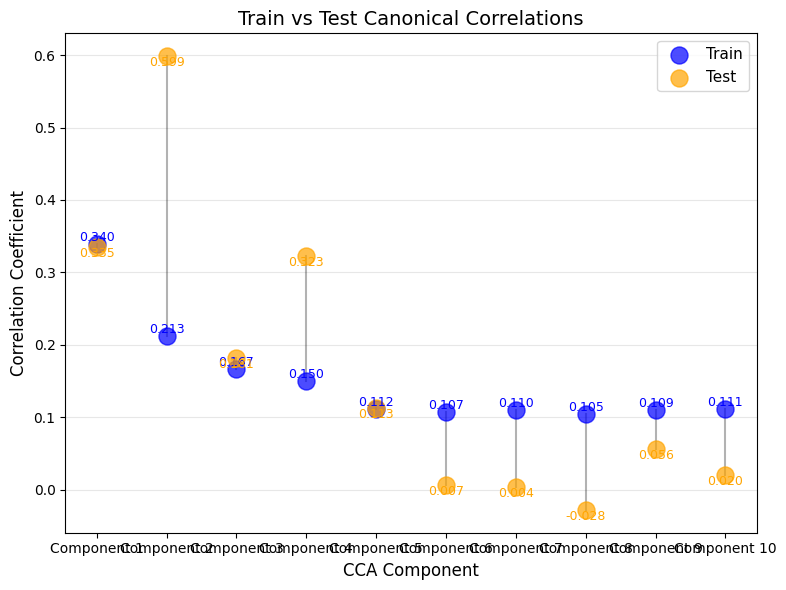

In [192]:
TCR_embedings.plot_train_test_corr(corr_train, corr_test)

### visualize CV scores

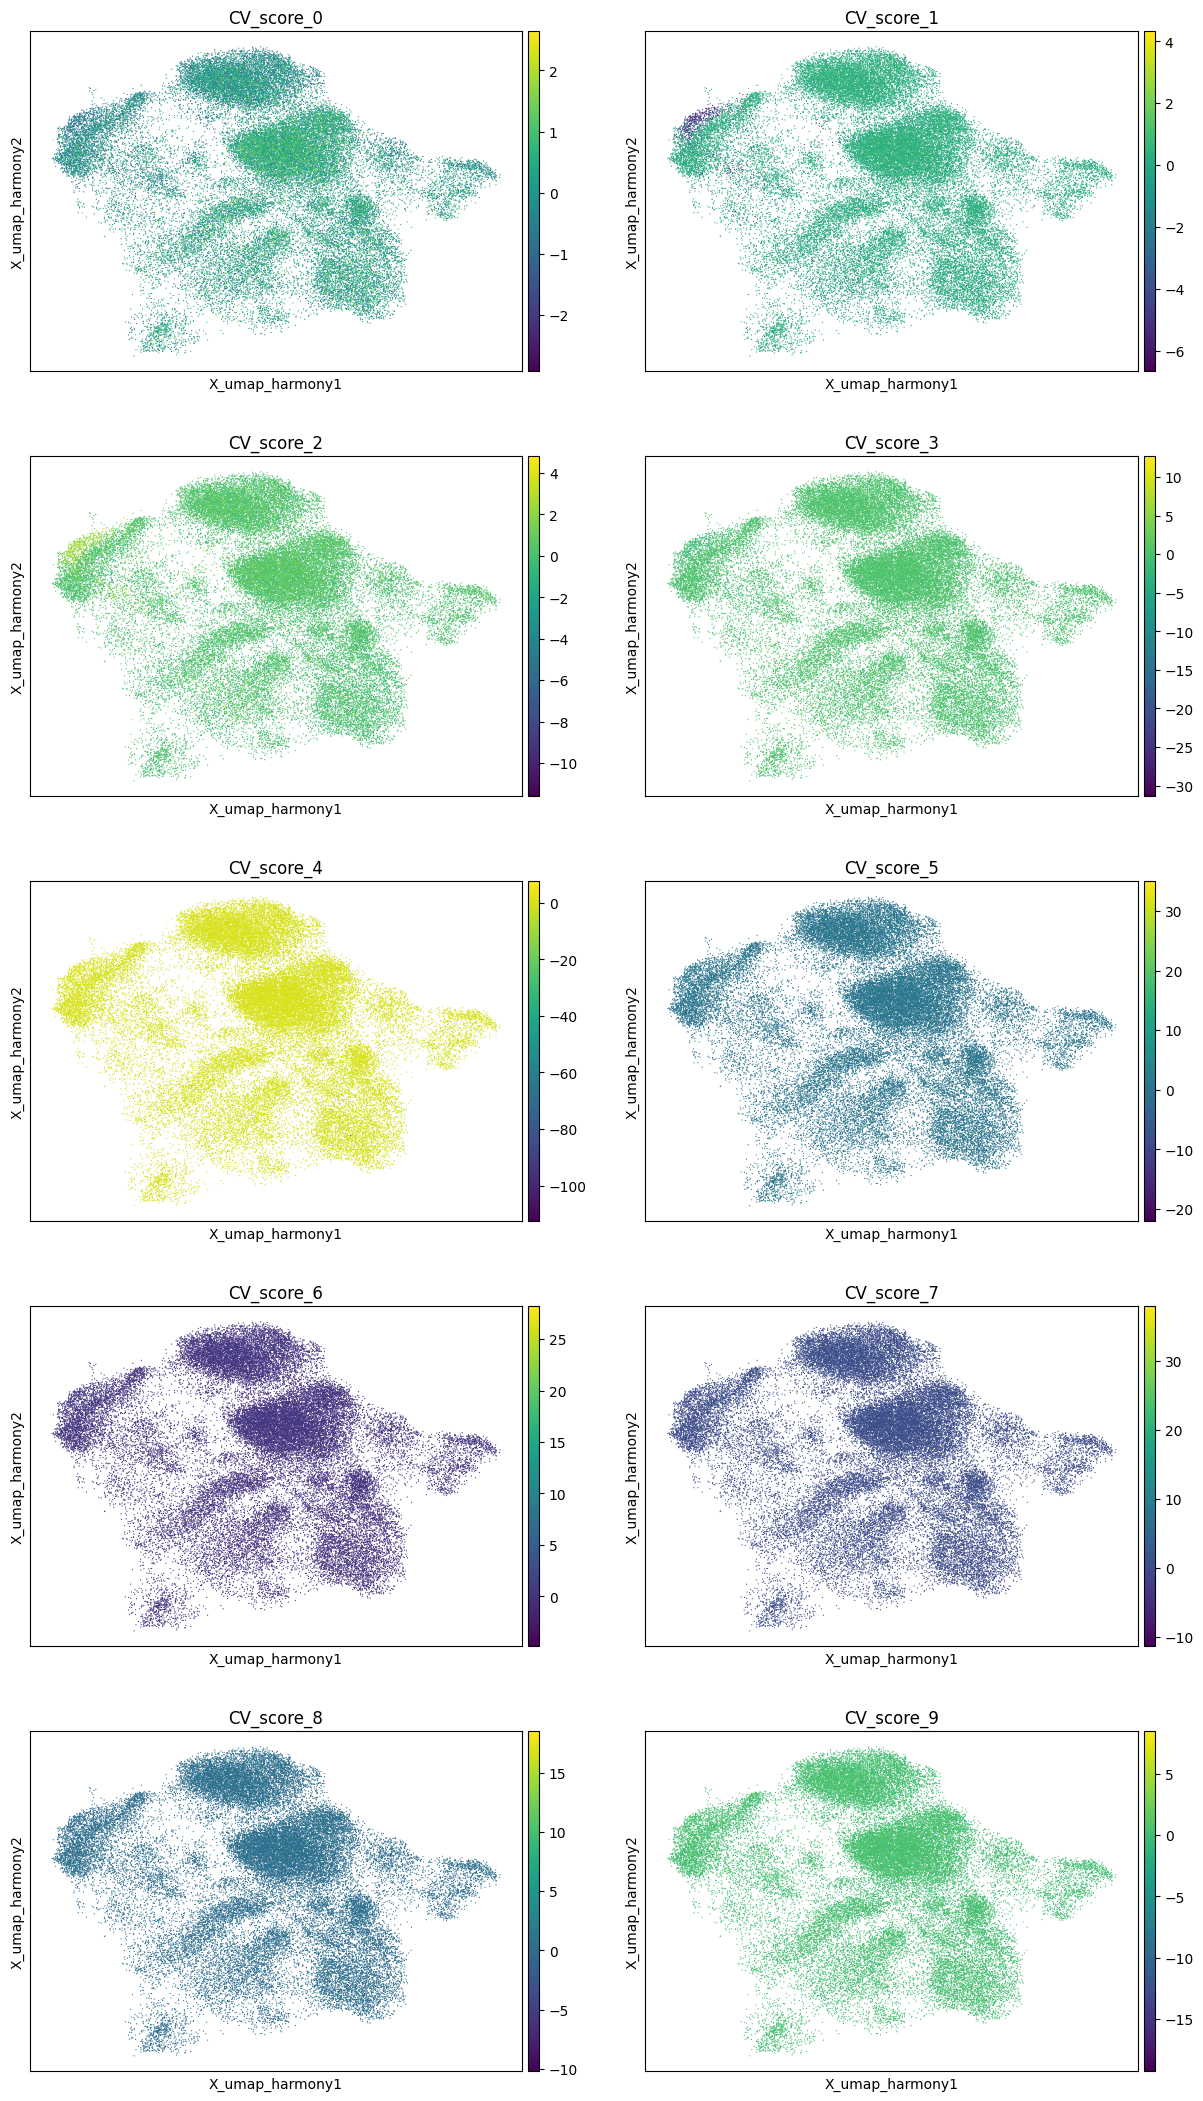

In [193]:
sc.pl.embedding(mdata["gex"], basis = gene_Umap, neighbors_key = neighbors_key, 
            color= cv_list, ncols=2,)

In [194]:
cutoff = 1

In [195]:
highlight_list = []
for i in range(0, dim_cca):
    cv_name = f'CV_score_{i}'
    tmp_col = cv_name + "_high"
    highlight_list.append(tmp_col)
    
    vals = mdata['gex'].obs[cv_name].copy()
    mdata['gex'].obs[tmp_col] = np.where(vals > cutoff, vals, np.nan)
    mdata['gex'].obs[cv_name + "_high_cat"] = np.where(vals > cutoff, True, False)
    mdata['gex'].obs[cv_name + "_high_cat"] = mdata['gex'].obs[cv_name + "_high_cat"].astype('category')
    mdata['gex'].obs[cv_name + "_high_cat"] = mdata['gex'].obs[cv_name + "_high_cat"].cat.remove_unused_categories()


# sc.pl.embedding(mdata["gex"], basis = gene_Umap, neighbors_key = neighbors_key, 
#             color= highlight_list, ncols=2,)

In [196]:
mdata['gex'].obs["CV_score_3_high_cat"].value_counts()

CV_score_3_high_cat
False    38789
True      1695
Name: count, dtype: int64

In [197]:
# top_n = 20
# for i in range(0,dim_cca):
#     cv_name = f'CV_score_{i}'
#     tmp_col = cv_name + "_high_cat"
    
#     sc.tl.rank_genes_groups(mdata["gex"], groupby= tmp_col, reference='rest',
#                         n_genes = top_n, method='t-test')
    
#     rank_df = sc.get.rank_genes_groups_df(mdata["gex"], None)
#     sc.pl.rank_genes_groups_dotplot(mdata["gex"], n_genes=top_n, groupby=tmp_col)

In [198]:
# what does each high-score cluster consists of
tissue_mask = mdata['gex'].obs['Tissue_group'].isin(['CNS'])
mdata_sub = mdata[test_mask]

all_results = []
abs_target = ['Tissue_group', 'cell_type', 'state']

# Precompute the overall (baseline) pool within the same tissue filter

# df_CV = TCR_embedings.subset_fractions_in_CV_scores(dim_cca, mdata_sub, abs_target, cutoff)
# df_CV

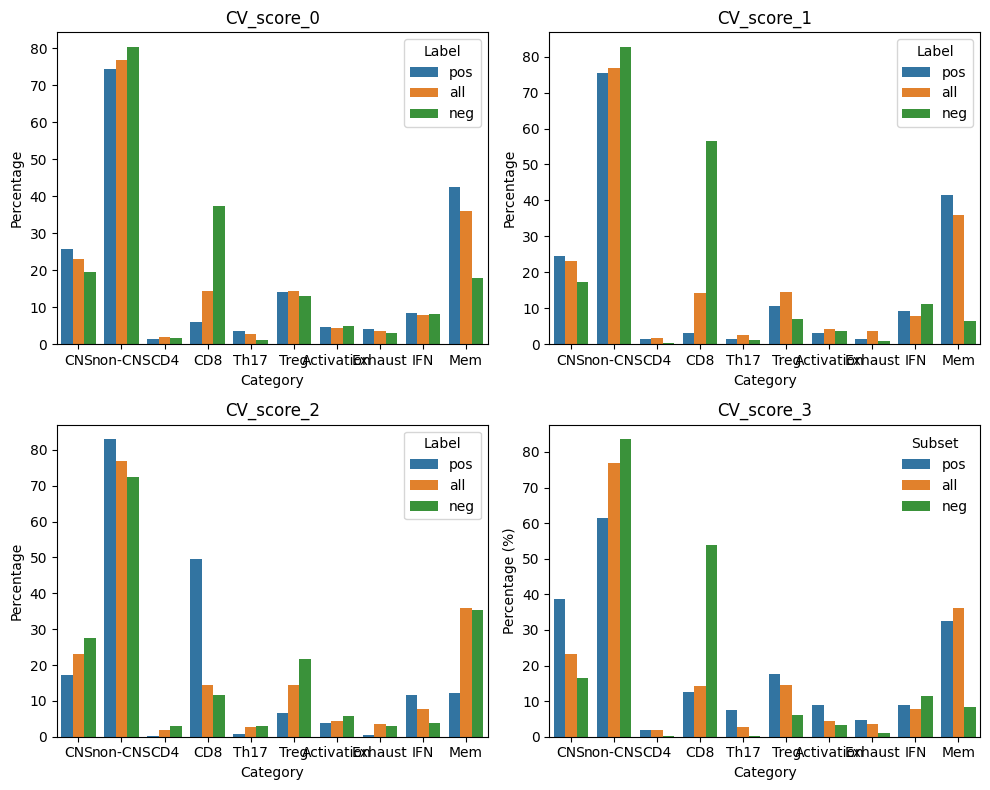

In [199]:
TCR_embedings.plot_subset_fractions_in_CV_scores(df_CV)

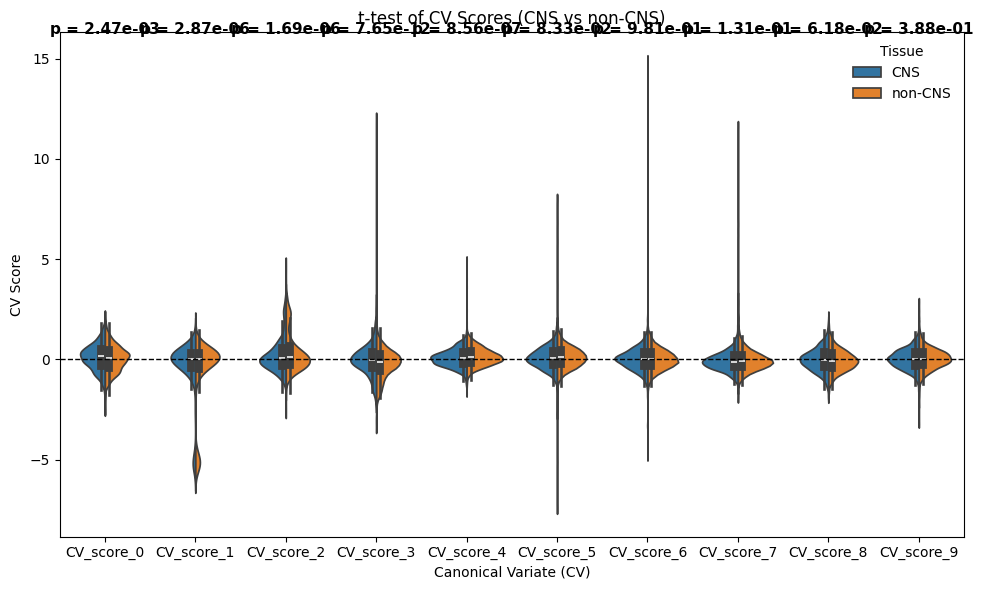

In [200]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------
obs = mdata_sub['gex'].obs.copy()

cv_cols = [f'CV_score_{i}' for i in range(dim_cca)]
df_long = obs.melt(id_vars='Tissue_group',
                   value_vars=cv_cols,
                   var_name='CV_component',
                   value_name='CV_score')

# ------------------------------------------------------------
# Violin plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
ax = sns.violinplot(
    data=df_long,
    x='CV_component',
    y='CV_score',
    hue='Tissue_group',
    split=True,
    inner='box',
    palette={'CNS': 'tab:blue', 'non-CNS': 'tab:orange'},
)

ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title("t-test of CV Scores (CNS vs non-CNS)")
plt.xlabel('Canonical Variate (CV)')
plt.ylabel('CV Score')
plt.legend(title='Tissue', frameon=False)

# ------------------------------------------------------------
# Student's t-test (unpaired)
# ------------------------------------------------------------
def cohens_d(x1, x2):
    x1, x2 = np.asarray(x1), np.asarray(x2)
    n1, n2 = len(x1), len(x2)
    s1, s2 = x1.std(ddof=1), x2.std(ddof=1)

    # pooled standard deviation
    s_pooled = np.sqrt(((n1 - 1)*s1**2 + (n2 - 1)*s2**2) / (n1 + n2 - 2))

    d = (x1.mean() - x2.mean()) / s_pooled
    return d

p_values = {}
cohen_d = {}
for cv in cv_cols:
    sub = df_long[df_long['CV_component'] == cv]
    cns_scores = sub.loc[sub['Tissue_group'] == 'CNS', 'CV_score']
    non_scores = sub.loc[sub['Tissue_group'] == 'non-CNS', 'CV_score']
    stat, p = ttest_ind(cns_scores, non_scores, equal_var=True, nan_policy='omit')
    p_values[cv] = p
    cohen_d[cv] = cohens_d(cns_scores, non_scores)
    
# ------------------------------------------------------------
# Annotate p-values above violins
# ------------------------------------------------------------
y_min, y_max = df_long['CV_score'].min(), df_long['CV_score'].max()
offset = (y_max - y_min) * 0.05

for i, cv in enumerate(cv_cols):
    p = p_values.get(cv)
    label = f"p = {p:.2e}" if p is not None else "NA"
    ax.text(i, y_max + offset, label,
            ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='black')

plt.tight_layout()
plt.show()


In [201]:
cohen_d

{'CV_score_0': np.float64(0.09658278063894779),
 'CV_score_1': np.float64(0.14939920468148202),
 'CV_score_2': np.float64(-0.1528450054465433),
 'CV_score_3': np.float64(0.2187581115573076),
 'CV_score_4': np.float64(-0.15714992499324903),
 'CV_score_5': np.float64(-0.055245219382322984),
 'CV_score_6': np.float64(-0.0007491482284234576),
 'CV_score_7': np.float64(-0.048207700726970115),
 'CV_score_8': np.float64(0.059569896457824276),
 'CV_score_9': np.float64(-0.027541935811368802)}

### correlations

In [202]:
# ANOVA tests: comparing all groups within each abs_target
from scipy.stats import f_oneway

anova_results = []

for i in range(0,dim_cca):
    cv_name = f'CV_score_{i}'
    
    for col in abs_target:
        # Get unique categories
        categories = mdata['gex'].obs[col].dropna().unique()
        
        # Collect all groups for this variable
        groups = []
        for cat in categories:
            group_data = mdata['gex'].obs[mdata['gex'].obs[col] == cat][cv_name].dropna().values
            if len(group_data) > 0:
                groups.append(group_data)
        
        # Perform ANOVA comparing all groups
        if len(groups) > 1:
            f_stat, p_value = f_oneway(*groups)
            
            anova_results.append({
                'CV_component': cv_name,
                'variable': col,
                'n_groups': len(groups),
                'F_statistic': round(f_stat, 4),
                'p_value': f'{p_value:.4e}',
                'significant': 'Yes' if p_value < 0.05 else 'No'
            })

df_anova = pd.DataFrame(anova_results)
# df_anova


In [203]:
# Calculate Pearson correlation between marker genes and CV scores
from scipy.stats import pearsonr
import seaborn as sns
    
def pearson_corr(adata, var1, markers, var_type='gene'):
    corr_results = []
    for cv_name in var1:
        cv_scores = adata.obs[cv_name].values
        for gene in markers:
            if gene in adata.var_names or gene in adata.obs:
                if var_type =='gene':
                    # Get gene expression values
                    gene_expr = adata[:, gene].X.toarray().flatten() if hasattr(adata[:, gene].X, 'toarray') else adata[:, gene].X.flatten()
                
                if var_type =='obs':
                    # Get gene set scores
                    gene_expr = gene_expr = adata.obs[gene].to_numpy().flatten() 

                # Calculate Pearson correlation
                corr, p_value = pearsonr(gene_expr, cv_scores)

                corr_results.append({
                    'CV_component': cv_name,
                    'gene': gene,
                    'pearson_r': round(corr, 4),
                    'p_value': f'{p_value:.4e}',
                    'significant': 'Yes' if p_value < 0.05 else 'No'
                })
            else:
                print(f"Warning: Input '{gene}' not found in dataset")

    df_gene_corr = pd.DataFrame(corr_results)
    corr_matrix = df_gene_corr.pivot(index='CV_component', columns='gene', values='pearson_r')
    return corr_matrix
    

### generate a tissue gene set score

In [209]:
top_n = 50
sc.tl.rank_genes_groups(mdata["gex"], groupby='tissue', groups = ['CNS'], reference='rest',
                        n_genes = top_n, method='t-test')
rank_df = sc.get.rank_genes_groups_df(mdata["gex"], None)
rank_df.head(5)

# mdata_HV = mdata["gex"][:, mdata["gex"].var_names.isin(rank_df['names'])]
# gex_df = mdata_HV.to_df()
# mdata_new = mu.MuData({'gex': mdata_HV, 'airr': mdata['airr']})
# view_gene = gex_df

,names,scores,logfoldchanges,pvals,pvals_adj
0,Gapdh,135.052811,2.724545,0.0,0.0
1,Uba52,126.095337,3.665213,0.0,0.0
2,Gm10076,121.828003,5.663047,0.0,0.0
3,Rpl9-ps6,118.076828,6.247917,0.0,0.0
4,Rpl10-ps3,107.880417,4.529308,0.0,0.0


In [210]:
CNS_HVGs = rank_df['names'].to_list()
sc.tl.score_genes(mdata['gex'], gene_list=CNS_HVGs, score_name='CNS_score')

In [211]:
sc.tl.rank_genes_groups(mdata["gex"], groupby='tissue', groups = ['Spleen'], reference='rest',
                        n_genes = top_n, method='t-test')
rank_df_spl = sc.get.rank_genes_groups_df(mdata["gex"], None)

SPL_HVGs = rank_df_spl['names'].to_list()
sc.tl.score_genes(mdata['gex'], gene_list=SPL_HVGs, score_name='SPL_score')

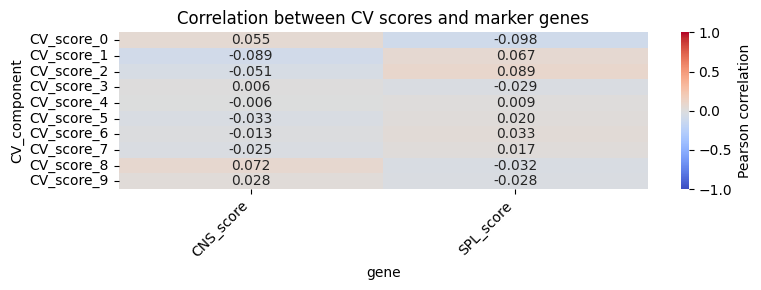

In [212]:
# Create the heatmap
cv_obs_name = [f'CV_score_{i}' for i in range(dim_cca)]
# scores = ['CD4score', 'CD8score', 'Tregscore', 'Th17score',
#           'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore',]

scores = ['CNS_score', 'SPL_score']

corr_matrix_obs = pearson_corr(mdata['gex'], cv_obs_name, scores, var_type='obs')

plt.figure(figsize=(8, 3))
sns.heatmap(corr_matrix_obs, annot=True, cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, fmt='.3f', cbar_kws={'label': 'Pearson correlation'})
plt.title('Correlation between CV scores and marker genes')
plt.xticks(rotation=45, ha='right')   # horizontal alignment
plt.yticks(rotation=0) 
plt.tight_layout()
plt.show()

In [213]:
aa

NameError: name 'aa' is not defined

In [ ]:
# LEE annotation markers
# marker_genes = ['Cd4','Cd8a', 'Foxp3', 'Ccr6', 'Il17', 'Isg15', 'Icos', 'Pdcd1', 'Ccr7']

# Ref markers
marker_genes = ['Cd4','Cd8a', 'Cd28', 'Foxp3', 'Ccr6', 'Ptprc', 'Ikzf2', 'Rtkn2', 'Klrg1', 'Isg15', 'Icos', 'Pdcd1', 'Ccr7']

corr_matrix_genes = pearson_corr(mdata['gex'], cv_obs_name, marker_genes, var_type='gene')

plt.figure(figsize=(8, 3))
sns.heatmap(corr_matrix_genes, annot=True, cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, fmt='.3f', cbar_kws={'label': 'Pearson correlation'})
plt.title('Correlation between CV scores and gene set scores')
plt.xticks(rotation=45, ha='right')   # horizontal alignment
plt.yticks(rotation=0) 
plt.tight_layout()
plt.show()

## biased logistic regression

In [ ]:
# Logistic Regression: predict CNS vs rest using TCR features
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# Create binary label: CNS vs rest
y = (mdata['gex'].obs['tissue'] == 'CNS').astype(int)

# Split data by fractions
# X_train, X_test, y_train, y_test = train_test_split(view_tcr, y, test_size=0.2, random_state=42, stratify=y)

# Split data based on mdata.obs['set']
train_mask = mdata.obs['set'] == 'train'
test_mask = mdata.obs['set'] == 'test'

X_train = view_tcr[train_mask]
X_test = view_tcr[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Apply RandomOverSampler to balance classes

from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_train, y_train = ros.fit_resample(X_train, y_train)
X_test, y_test = ros.fit_resample(X_test, y_test)

print(f"\nAfter oversampling:")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Train Logistic Regression
lr_model = LogisticRegression(penalty='l2', max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
# Predictions
y_pred = lr_model.predict(X_test)
y_pred_proba = lr_model.predict_proba(X_test)[:, 1]

# Evaluation
print(f"\n{'='*60}")
print("Performance on Test Set:")
print(f"{'='*60}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-CNS', 'CNS']))

print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

In [ ]:
# Plot distribution of decision function for both classes
# score_p = lr_model.decision_function(X_test)
# decision_scores = (score_p - np.mean(score_p)) / np.std(score_p)

decision_scores = y_pred_proba

# Separate scores by class
scores_non_cns = decision_scores[y_test == 0]
scores_cns = decision_scores[y_test == 1]

df1 = pd.DataFrame({'tissue': 'CNS', 'score':scores_cns})
df2 =  pd.DataFrame({'tissue': 'Non-CNS', 'score':scores_non_cns})
df_s = pd.concat([df1,df2], axis=0)

ax = sns.violinplot(
    data=df_s,
    y='score',
    hue='tissue',
    split=True,
    inner='quart',
    # palette={'CNS': 'tab:blue', 'non-CNS': 'tab:orange'},
)
ax.axhline(y=0.5, color='black', linestyle='--', linewidth=1)

plt.title("t-test of CV Scores (CNS vs non-CNS)")
plt.xlabel('Canonical Variate (CV)')
plt.ylabel('CV Score')
plt.legend(title='Tissue', frameon=False)

In [ ]:
mdata.uns['lr_coef'] = lr_model.coef_
mdata.uns['lr_intercept'] = lr_model.intercept_

In [ ]:
mdata

In [ ]:
# visualize logit regression scores  ##
y_train_score = lr_model.predict_proba(X_train)[:, 1]
y_train_score = pd.Series(y_train_score, index=y_train.index)
y_test_score = pd.Series(y_pred_proba, index=y_test.index)
TCR_logit_score = pd.concat([y_train_score, y_test_score], axis=0)
TCR_logit_score

In [ ]:
# TCR_logit_score_filtered = TCR_logit_score[(TCR_logit_score < 0.1) | (TCR_logit_score > 0.9)]
# mdata["gex"].obs["TCR_logit_score"] = TCR_logit_score_filtered
# sc.pl.embedding(mdata["gex"], basis = gene_Umap, neighbors_key = 'neighbors_harmony', 
#             color="TCR_logit_score", ncols=1,)

# Save

In [ ]:
aa

In [ ]:
import anndata as ad
ad.settings.allow_write_nullable_strings = True
mdata.write(f'{filename}_cloned_singlePerClone.h5mu')

In [ ]:
mdata

# rCCA cross vali

In [ ]:
feat_alpha_x = [0.1, 1, 10]
feat_alpha_y = [0.1, 1, 10]
# feat_alpha_x = [1]
# feat_alpha_y = [1]

TCR_score_CVs = []
CNS_mask = mdata['gex'].obs['Tissue_group'] == 'CNS'

# Track maximum absolute difference and corresponding data
max_abs_diff = -np.inf
best_view_gene_c_train = None
best_view_tcr_c_train = None
best_view_gene_c_test = None
best_view_tcr_c_test = None
best_alpha_x = None
best_alpha_y = None

for a_x in feat_alpha_x:
    for a_y in feat_alpha_y:
        cca = TCR_embedings.rCCA(n_components=4, alpha_x=a_x, alpha_y = a_y)
        print('alpha_X='+str(a_x) + 'alpha_y='+str(a_y))
        view_gene_c_train, view_tcr_c_train = cca.fit_transform(view_gene_train, view_tcr_train)
        view_gene_c_test, view_tcr_c_test = cca.transform(view_gene_test, view_tcr_test)
        
        # Combine for full dataset storage 
        view_gene_t = np.zeros((mdata.n_obs, 4))
        view_tcr_t = np.zeros((mdata.n_obs, 4))
        view_gene_t[train_mask] = view_gene_c_train
        view_gene_t[test_mask] = view_gene_c_test
        view_tcr_t[train_mask] = view_tcr_c_train
        view_tcr_t[test_mask] = view_tcr_c_test
        
        TCR_score_CVs.append(view_tcr_t)
        
        CV_CNS = view_tcr_t[CNS_mask]
        cv_notCNS = view_tcr_t[~CNS_mask]
        
        mean_CNS_CVs = np.mean(CV_CNS,axis=0)
        mean_notCNS_CVs = np.mean(cv_notCNS,axis=0)
        
        diff = mean_CNS_CVs - mean_notCNS_CVs
        print(diff)
        
        # Find maximum absolute difference across all CV components
        abs_diff = np.abs(diff)
        max_abs_diff_in_this_iter = np.max(abs_diff)
        
        # Update best if this is the maximum so far
        if max_abs_diff_in_this_iter > max_abs_diff:
            max_abs_diff = max_abs_diff_in_this_iter
            best_view_gene_c_train = view_gene_c_train.copy()
            best_view_tcr_c_train = view_tcr_c_train.copy()
            best_view_gene_c_test = view_gene_c_test.copy()
            best_view_tcr_c_test = view_tcr_c_test.copy()
            best_alpha_x = a_x
            best_alpha_y = a_y

print(f"\nMaximum absolute difference found: {max_abs_diff:.4f}")
print(f"Best alpha_x: {best_alpha_x}, Best alpha_y: {best_alpha_y}")

# Pass the best corresponding data to train_test_corr
TCR_embedings.train_test_corr(best_view_gene_c_train, best_view_tcr_c_train, best_view_gene_c_test, best_view_tcr_c_test)


# cross-set test

In [ ]:
aa

In [ ]:
#### Compare performance across all GSE subsets as test groups
# Get unique GSE values
unique_gses = mdata.obs['GSE'].unique()
print(f"Found {len(unique_gses)} unique GSE values: {unique_gses.tolist()}")

# Store results for comparison
results_summary = []


In [ ]:
# Loop through each GSE as test set
for test_gse in unique_gses:
    print(f"\n{'='*80}")
    print(f"Testing with {test_gse} as test set")
    print(f"{'='*80}")
    
    # Set train/test split
    mdata.obs.loc[mdata.obs['GSE'].isin([test_gse]), 'set'] = 'test'
    mdata.obs.loc[~mdata.obs['GSE'].isin([test_gse]), 'set'] = 'train'
    
    train_size = (mdata.obs['set'] == 'train').sum()
    test_size = (mdata.obs['set'] == 'test').sum()
#     print(f"Train set: {train_size} samples, Test set: {test_size} samples")
    
    # Prepare feature arrays (same as before)
    # arrs_tcr = []
    # for key, value in mdata.obsm.items():
    #     arrs_tcr.append(value)
    
#     view_tcr = np.concatenate(arrs_tcr, axis=1)
#     view_tcr = np.concatenate([view_tcr, mdata.obs['VDJ_1_cdr3_aa_length'].to_numpy().reshape(-1, 1),
#                                mdata.obs['VJ_1_cdr3_aa_length'].to_numpy().reshape(-1, 1)], axis=1)
    
#     scaler = StandardScaler()
#     view_tcr = scaler.fit_transform(view_tcr)
    
    # Split data
    train_mask = mdata.obs['set'] == 'train'
    test_mask = mdata.obs['set'] == 'test'
    
    X_train = view_tcr[train_mask]
    X_test = view_tcr[test_mask]
    
    # Create binary label: CNS vs rest
    y = (mdata['gex'].obs['tissue'] == 'CNS').astype(int)
    y_train = y[train_mask]
    y_test = y[test_mask]
    
    # ===== Logistic Regression Evaluation =====
    print(f"\n--- Logistic Regression Evaluation ---")
    
    # Apply RandomOverSampler to balance classes
    from imblearn.over_sampling import RandomOverSampler
    ros = RandomOverSampler(random_state=42)
    X_train_balanced, y_train_balanced = ros.fit_resample(X_train, y_train)
    
    # Train Logistic Regression
    lr_model = LogisticRegression(max_iter=1000, random_state=42)
    lr_model.fit(X_train_balanced, y_train_balanced)
    
    # Predictions
    y_pred = lr_model.predict(X_test)
    y_pred_proba = lr_model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    lr_accuracy = accuracy_score(y_test, y_pred)
    lr_roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    print(f"Accuracy: {lr_accuracy:.4f}")
    print(f"ROC AUC: {lr_roc_auc:.4f}")
    
    # ===== CCA Evaluation =====
    print(f"\n--- CCA Evaluation ---")
    
    # Prepare gene expression view
    view_gene = mdata['gex'].obsm[gene_PCA]
    scaler_gene = StandardScaler()
    view_gene_scaled = scaler_gene.fit_transform(view_gene)
    
    view_gene_train = view_gene_scaled[train_mask]
    view_gene_test = view_gene_scaled[test_mask]
    view_tcr_train = view_tcr[train_mask]
    view_tcr_test = view_tcr[test_mask]
    
    # Fit CCA on train set
    cca = CCA(n_components=4)
    view_gene_c_train, view_tcr_c_train = cca.fit_transform(view_gene_train, view_tcr_train)
    
    # Transform test set
    view_gene_c_test, view_tcr_c_test = cca.transform(view_gene_test, view_tcr_test)
    
    # Calculate correlations for each component
    cca_correlations_train = []
    cca_correlations_test = []
    
    for i in range(4):
        corr_train = np.corrcoef(view_gene_c_train[:, i], view_tcr_c_train[:, i])[0, 1]
        corr_test = np.corrcoef(view_gene_c_test[:, i], view_tcr_c_test[:, i])[0, 1]
        cca_correlations_train.append(corr_train)
        cca_correlations_test.append(corr_test)
    
    # Average correlation (can also use max or sum)
    avg_train_corr = np.mean(cca_correlations_train)
    avg_test_corr = np.mean(cca_correlations_test)
    cca_drop = avg_train_corr - avg_test_corr  # Generalization gap
    
    print(f"Average Train Correlation: {avg_train_corr:.4f}")
    print(f"Average Test Correlation: {avg_test_corr:.4f}")
    print(f"Generalization Gap: {cca_drop:.4f}")
    
    # Store results
    result = {
        'test_gse': test_gse,
        'train_size': train_size,
        'test_size': test_size,
        'lr_accuracy': lr_accuracy,
        'lr_roc_auc': lr_roc_auc,
        'cca_train_corr': avg_train_corr,
        'cca_test_corr': avg_test_corr,
        'cca_generalization_gap': cca_drop,
        'cca_comp1_train': cca_correlations_train[0],
        'cca_comp1_test': cca_correlations_test[0],
        'cca_comp2_train': cca_correlations_train[1],
        'cca_comp2_test': cca_correlations_test[1],
        'cca_comp3_train': cca_correlations_train[2],
        'cca_comp3_test': cca_correlations_test[2],
        'cca_comp4_train': cca_correlations_train[3],
        'cca_comp4_test': cca_correlations_test[3],
    }
    results_summary.append(result)
    
    print(f"\nCompleted evaluation for {test_gse}")

# Convert results to DataFrame
results_df = pd.DataFrame(results_summary)


In [ ]:
# Identify best performing test groups
print(f"\n{'='*80}")
print("BEST PERFORMING TEST GROUPS")
print(f"{'='*80}")

# Best by Logistic Regression Accuracy
best_lr_acc = results_df.loc[results_df['lr_accuracy'].idxmax()]
print(f"\nBest Logistic Regression Accuracy:")
print(f"  Test GSE: {best_lr_acc['test_gse']}")
print(f"  Accuracy: {best_lr_acc['lr_accuracy']:.4f}")
print(f"  ROC AUC: {best_lr_acc['lr_roc_auc']:.4f}")

# Best by Logistic Regression ROC AUC
best_lr_auc = results_df.loc[results_df['lr_roc_auc'].idxmax()]
print(f"\nBest Logistic Regression ROC AUC:")
print(f"  Test GSE: {best_lr_auc['test_gse']}")
print(f"  Accuracy: {best_lr_auc['lr_accuracy']:.4f}")
print(f"  ROC AUC: {best_lr_auc['lr_roc_auc']:.4f}")

# Best by CCA Test Correlation (highest generalization)
best_cca_test = results_df.loc[results_df['cca_test_corr'].idxmax()]
print(f"\nBest CCA Test Correlation (Best Generalization):")
print(f"  Test GSE: {best_cca_test['test_gse']}")
print(f"  Test Correlation: {best_cca_test['cca_test_corr']:.4f}")
print(f"  Train Correlation: {best_cca_test['cca_train_corr']:.4f}")
print(f"  Generalization Gap: {best_cca_test['cca_generalization_gap']:.4f}")

# Best by smallest CCA generalization gap (most stable)
best_cca_gap = results_df.loc[results_df['cca_generalization_gap'].idxmin()]
print(f"\nBest CCA Generalization (Smallest Gap):")
print(f"  Test GSE: {best_cca_gap['test_gse']}")
print(f"  Test Correlation: {best_cca_gap['cca_test_corr']:.4f}")
print(f"  Train Correlation: {best_cca_gap['cca_train_corr']:.4f}")
print(f"  Generalization Gap: {best_cca_gap['cca_generalization_gap']:.4f}")

# Combined score (normalized metrics)
results_df['combined_score'] = (
    results_df['lr_roc_auc'].rank(pct=True) * 0.5 +  # 50% weight on LR ROC AUC
    results_df['cca_test_corr'].rank(pct=True) * 0.3 +  # 30% weight on CCA test corr
    (1 - results_df['cca_generalization_gap'].rank(pct=True) / results_df['cca_generalization_gap'].max()) * 0.2  # 20% weight on small gap
)

best_combined = results_df.loc[results_df['combined_score'].idxmax()]
print(f"\nBest Combined Score:")
print(f"  Test GSE: {best_combined['test_gse']}")
print(f"  Combined Score: {best_combined['combined_score']:.4f}")
print(f"  LR ROC AUC: {best_combined['lr_roc_auc']:.4f}")
print(f"  CCA Test Correlation: {best_combined['cca_test_corr']:.4f}")
print(f"  CCA Generalization Gap: {best_combined['cca_generalization_gap']:.4f}")

# Display sorted results
print(f"\n{'='*80}")
print("RESULTS SORTED BY COMBINED SCORE")
print(f"{'='*80}")
results_df_sorted = results_df.sort_values('combined_score', ascending=False)
print(results_df_sorted[['test_gse', 'lr_accuracy', 'lr_roc_auc', 'cca_test_corr', 'cca_generalization_gap', 'combined_score']].to_string(index=False))


In [ ]:
# Visualize performance comparison across test groups
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Logistic Regression ROC AUC
axes[0, 0].bar(results_df['test_gse'], results_df['lr_roc_auc'], color='steelblue', alpha=0.7)
axes[0, 0].set_ylabel('ROC AUC', fontsize=12)
axes[0, 0].set_title('Logistic Regression ROC AUC by Test GSE', fontsize=13, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[0, 0].legend()

# Plot 2: CCA Test Correlation
axes[0, 1].bar(results_df['test_gse'], results_df['cca_test_corr'], color='coral', alpha=0.7)
axes[0, 1].set_ylabel('Average Correlation', fontsize=12)
axes[0, 1].set_title('CCA Test Correlation by Test GSE', fontsize=13, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: CCA Generalization Gap
axes[1, 0].bar(results_df['test_gse'], results_df['cca_generalization_gap'], color='gold', alpha=0.7)
axes[1, 0].set_ylabel('Generalization Gap', fontsize=12)
axes[1, 0].set_title('CCA Generalization Gap (Train - Test)', fontsize=13, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Combined Score
axes[1, 1].bar(results_df_sorted['test_gse'], results_df_sorted['combined_score'], color='mediumseagreen', alpha=0.7)
axes[1, 1].set_ylabel('Combined Score', fontsize=12)
axes[1, 1].set_title('Combined Performance Score (Sorted)', fontsize=13, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Additional plot: CCA component-wise comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results_df))
width = 0.2

# Plot test correlations for each component
for i in range(4):
    ax.bar(x + i*width, results_df[f'cca_comp{i+1}_test'], width, 
           label=f'Component {i+1}', alpha=0.8)

ax.set_xlabel('Test GSE', fontsize=12)
ax.set_ylabel('Test Correlation', fontsize=12)
ax.set_title('CCA Test Correlations by Component', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df['test_gse'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
